# 01 · EDA: Medical Appointment No Shows

Objetivo: entender el dataset limpio antes de construir features. Se parte de
`data/processed/appointments_clean.parquet`, generado por `make data`.

Convenciones:
- `no_show = 1` significa que el paciente **no asistió** (en el CSV crudo, `No-show == "Yes"`).
- `lead_days` = días entre la fecha de agendamiento y la fecha de la cita. Aquí se calcula solo
  para explorar; la definición oficial vivirá en `features.py` (Fase 2).
- `sms_received` se analiza aquí, pero **no** será feature (decisión confirmada).

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from noshow_guard.config import PATHS
from noshow_guard.data import load_clean

sns.set_theme(style="whitegrid")
FIG_DIR = PATHS.reports / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_clean()
df["lead_days"] = (df["appointment_date"] - df["scheduled_date"]).dt.days
print(json.dumps(json.loads(PATHS.cleaning_report.read_text(encoding="utf-8")), indent=2))
print(df.shape)

{
  "raw_sha256": "9132d3e7d0246617df9041d3764f20ad6f08e7b0d9f0997fa254fc5e52eda27d",
  "rows_in": 110527,
  "rows_out": 110511,
  "dropped": {
    "patient_id_corrupto": 5,
    "edad_fuera_de_rango": 6,
    "cita_antes_de_agendamiento": 5
  }
}
(110511, 16)


In [2]:
def rate_table(frame: pd.DataFrame, by: str | list[str]) -> pd.DataFrame:
    """Tasa de no-show y tamaño por grupo."""
    return (
        frame.groupby(by, observed=True)["no_show"]
        .agg(no_show_rate="mean", n="size")
        .round({"no_show_rate": 3})
    )


def save(fig: plt.Figure, name: str) -> None:
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"eda_{name}.png", dpi=110)

## 1. Variable objetivo

In [3]:
print(df["no_show"].value_counts().rename({0: "asistió", 1: "no asistió"}))
print(f"Tasa global de no-show: {df['no_show'].mean():.4f}")

no_show
asistió       88200
no asistió    22311
Name: count, dtype: int64
Tasa global de no-show: 0.2019


## 2. Antelación (lead time)

Se espera que sea la variable más fuerte. Las citas del mismo día (`lead_days == 0`) quedan fuera
del alcance del modelo, así que se muestran aparte.

,no_show_rate,n
lead_bin,,
0,0.046,38559
1-2,0.227,11938
3-7,0.250,20242
8-14,0.305,12025
15-30,0.326,17370
31-60,0.341,8282
61+,0.284,2095


Citas del mismo día: 38559 (34.9%)
count    71952.0
mean        15.6
std         16.5
min          1.0
25%          4.0
50%          9.0
75%         22.0
max        179.0
Name: lead_days, dtype: float64


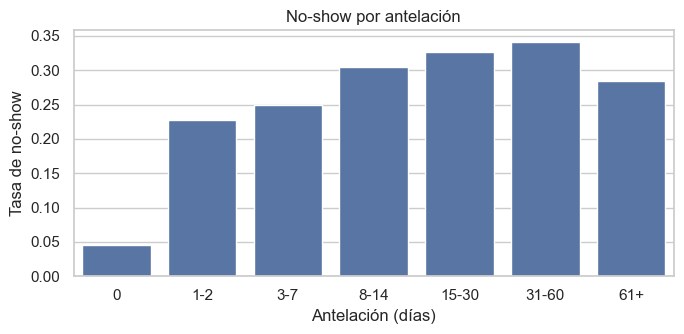

In [4]:
lead_bins = [-1, 0, 2, 7, 14, 30, 60, 1000]
lead_labels = ["0", "1-2", "3-7", "8-14", "15-30", "31-60", "61+"]
df["lead_bin"] = pd.cut(df["lead_days"], bins=lead_bins, labels=lead_labels)
lead_rates = rate_table(df, "lead_bin")
display(lead_rates)
print(f"Citas del mismo día: {(df['lead_days'] == 0).sum()} ({(df['lead_days'] == 0).mean():.1%})")
print(df.loc[df["lead_days"] > 0, "lead_days"].describe().round(1))

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(x=lead_rates.index.astype(str), y=lead_rates["no_show_rate"], color="C0", ax=ax)
ax.set(xlabel="Antelación (días)", ylabel="Tasa de no-show", title="No-show por antelación")
save(fig, "lead_time")

## 3. Edad

,no_show_rate,n
age_bin,,
0-5,0.186,11731
6-12,0.228,9303
13-17,0.266,6342
18-25,0.251,11218
26-35,0.228,14403
36-45,0.211,14579
46-55,0.184,15437
56-65,0.158,14203
66-75,0.151,7909


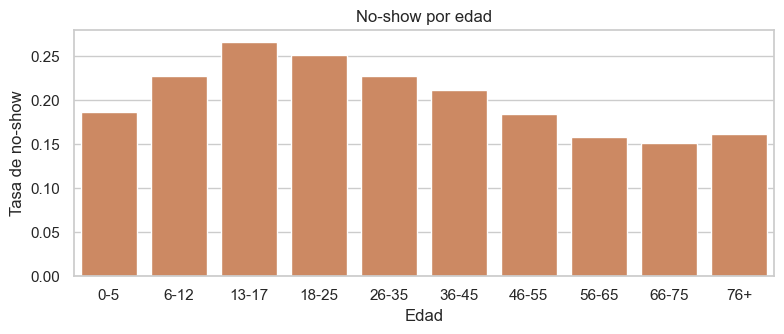

In [5]:
age_bins = [-1, 5, 12, 17, 25, 35, 45, 55, 65, 75, 110]
age_labels = ["0-5", "6-12", "13-17", "18-25", "26-35", "36-45", "46-55", "56-65", "66-75", "76+"]
df["age_bin"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)
age_rates = rate_table(df, "age_bin")
display(age_rates)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=age_rates.index.astype(str), y=age_rates["no_show_rate"], color="C1", ax=ax)
ax.set(xlabel="Edad", ylabel="Tasa de no-show", title="No-show por edad")
save(fig, "age")

## 4. Día de la semana y fecha de la cita

Con solo 27 fechas de cita, el día de la semana podría actuar como proxy de fechas concretas
(por ejemplo, un feriado). Se revisa cuántas fechas distintas hay por día y cómo varía la tasa
entre fechas del mismo día.

In [6]:
weekday_names = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
df["weekday"] = df["appointment_date"].dt.dayofweek.map(dict(enumerate(weekday_names)))
scope = df[df["lead_days"] > 0]
weekday_rates = rate_table(scope, "weekday").reindex(
    [d for d in weekday_names if d in set(scope["weekday"])]
)
weekday_rates["fechas_distintas"] = scope.groupby("weekday")["appointment_date"].nunique()
display(weekday_rates)

per_date = rate_table(scope, ["appointment_date"]).reset_index()
per_date["weekday"] = per_date["appointment_date"].dt.dayofweek.map(dict(enumerate(weekday_names)))
display(per_date.groupby("weekday")["no_show_rate"].agg(["min", "max", "std"]).round(3))

,no_show_rate,n,fechas_distintas
weekday,,,
Lun,0.302,14579,5
Mar,0.287,16462,6
Mié,0.271,17044,6
Jue,0.273,11323,4
Vie,0.294,12513,5
Sáb,0.290,31,1


,min,max,std
weekday,,,
Jue,0.264,0.285,0.009
Lun,0.270,0.331,0.026
Mar,0.244,0.328,0.032
Mié,0.240,0.315,0.026
Sáb,0.290,0.290,NaN
Vie,0.271,0.329,0.027


Fechas con cita: 27
Rango de citas: 2016-04-29 -> 2016-06-08
Rango de agendamiento: 2015-11-10 07:13:56 -> 2016-06-08 20:07:23


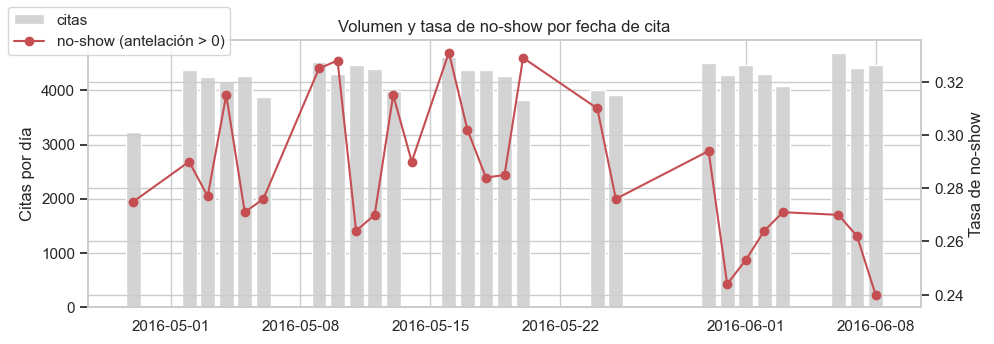

In [7]:
all_dates = rate_table(df, ["appointment_date"]).reset_index()
fig, ax1 = plt.subplots(figsize=(10, 3.5))
ax1.bar(all_dates["appointment_date"], all_dates["n"], color="lightgray", label="citas")
ax1.set_ylabel("Citas por día")
ax2 = ax1.twinx()
ax2.plot(
    per_date["appointment_date"],
    per_date["no_show_rate"],
    "o-",
    color="C3",
    label="no-show (antelación > 0)",
)
ax2.set_ylabel("Tasa de no-show")
ax1.set_title("Volumen y tasa de no-show por fecha de cita")
fig.legend(loc="upper left")
save(fig, "by_date")

print("Fechas con cita:", df["appointment_date"].nunique())
print(
    "Rango de citas:",
    df["appointment_date"].min().date(),
    "->",
    df["appointment_date"].max().date(),
)
print("Rango de agendamiento:", df["scheduled_at"].min(), "->", df["scheduled_at"].max())

## 5. Barrio

81 barrios con tamaños muy desiguales. Barrios pequeños dan tasas ruidosas, lo que importa para
decidir cómo codificarlos en la Fase 2.

In [8]:
nb = rate_table(scope, "neighbourhood").sort_values("no_show_rate")
print("Barrios:", len(nb), "| con < 100 citas (antelación > 0):", (nb["n"] < 100).sum())
big = nb[nb["n"] >= 500]
display(pd.concat([big.head(5), big.tail(5)]))
display(nb[nb["n"] < 100])

Barrios: 80 | con < 100 citas (antelación > 0): 6


,no_show_rate,n
neighbourhood,,
DO QUADRO,0.219,558
JARDIM DA PENHA,0.225,2655
VILA RUBIM,0.227,598
GOIABEIRAS,0.229,533
REPÚBLICA,0.230,592
ILHA DO PRÍNCIPE,0.325,1503
SANTOS DUMONT,0.349,877
ITARARÉ,0.365,2381
JESUS DE NAZARETH,0.375,1755


,no_show_rate,n
neighbourhood,,
ILHA DO BOI,0.087,23
AEROPORTO,0.200,5
MORADA DE CAMBURI,0.205,78
ILHA DO FRADE,0.250,8
PONTAL DE CAMBURI,0.293,41
ILHAS OCEÂNICAS DE TRINDADE,1.000,2


## 6. Género, beca y condiciones

In [9]:
binary_cols = ["gender", "scholarship", "hypertension", "diabetes", "alcoholism", "handicap"]
display(pd.concat({c: rate_table(scope, c) for c in binary_cols}, names=["variable", "valor"]))

no_show_rate      n
variable     valor                     
gender       F             0.284  48064
             M             0.287  23888
scholarship  0             0.279  65281
             1             0.350   6671
hypertension 0             0.298  56921
             1             0.235  15031
diabetes     0             0.288  66575
             1             0.250   5377
alcoholism   0             0.284  70130
             1             0.341   1822
handicap     0             0.286  70648
             1             0.249   1182
             2             0.304    112
             3             0.250      8
             4             0.500      2

## 7. SMS (solo análisis, no será feature)

La comparación cruda sugiere que recibir SMS *aumenta* el no-show. Al estratificar por antelación
se ve que es un efecto de confusión: el SMS solo se envió a citas con más antelación, y la
antelación es la que se asocia al no-show.

,no_show_rate,n
sms_received,,
0,0.167,75031
1,0.276,35480


Antelación mínima con SMS: 3


no_show_rate            n       
sms_received            0      1     0      1
lead_bin                                     
3-7                 0.266  0.238  8695  11547
8-14                0.338  0.281  5021   7004
15-30               0.369  0.298  6851  10519
31-60               0.383  0.315  3223   5059
61+                 0.339  0.255   744   1351

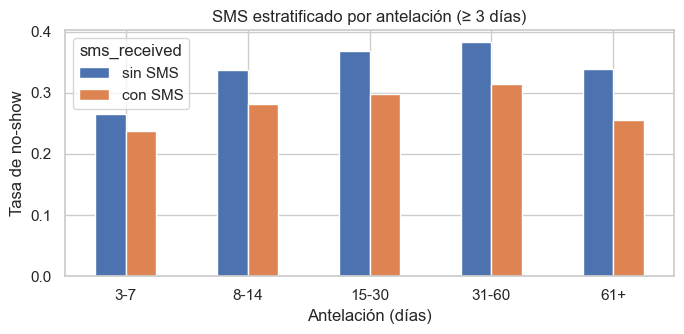

In [10]:
display(rate_table(df, "sms_received"))
print("Antelación mínima con SMS:", df.loc[df["sms_received"] == 1, "lead_days"].min())
sms_strat = rate_table(df[df["lead_days"] >= 3], ["lead_bin", "sms_received"]).unstack(
    "sms_received"
)
display(sms_strat)

plot_df = sms_strat["no_show_rate"].rename(columns={0: "sin SMS", 1: "con SMS"})
fig, ax = plt.subplots(figsize=(7, 3.5))
plot_df.plot(kind="bar", ax=ax, rot=0)
ax.set(
    xlabel="Antelación (días)",
    ylabel="Tasa de no-show",
    title="SMS estratificado por antelación (≥ 3 días)",
)
save(fig, "sms_stratified")

## 8. Pacientes repetidos e historial disponible

Pregunta clave para la Fase 2: si el historial solo puede usar citas **terminadas antes del
agendamiento** (`appointment_date < scheduled_date`), ¿cuántas citas tienen historial?
Como las citas solo cubren 2016-04-29 a 2016-06-08, se espera poco historial.

In [11]:
per_patient = df.groupby("patient_id").size()
print(
    "Pacientes:",
    len(per_patient),
    "| con > 1 cita:",
    (per_patient > 1).sum(),
    "| máx:",
    per_patient.max(),
)
print(per_patient.value_counts().sort_index().head(6))

# Historial exploratorio: citas del mismo paciente con fecha de cita < fecha de agendamiento.
pairs = scope[["appointment_id", "patient_id", "scheduled_date", "no_show"]].merge(
    df[["patient_id", "appointment_date", "no_show"]].rename(columns={"no_show": "prev_no_show"}),
    on="patient_id",
)
pairs = pairs[pairs["appointment_date"] < pairs["scheduled_date"]]
hist = pairs.groupby("appointment_id").agg(
    prev_n=("prev_no_show", "size"), prev_ns=("prev_no_show", "sum")
)
scope_hist = scope.set_index("appointment_id").join(hist).fillna({"prev_n": 0, "prev_ns": 0})
share_with_history = (scope_hist["prev_n"] > 0).mean()
print(f"Citas (antelación > 0) con al menos una cita previa terminada: {share_with_history:.1%}")
scope_hist["hist_group"] = pd.cut(
    scope_hist["prev_n"], bins=[-1, 0, 1000], labels=["sin historial", "con historial"]
)
display(rate_table(scope_hist, "hist_group"))
with_hist = scope_hist[scope_hist["prev_n"] > 0]
display(
    rate_table(
        with_hist.assign(tuvo_no_show_previo=(with_hist["prev_ns"] > 0).astype(int)),
        "tuvo_no_show_previo",
    )
)

Pacientes: 62291 | con > 1 cita: 24377 | máx: 88
1    37914
2    13895
3     5499
4     2368
5     1117
6      553
Name: count, dtype: int64
Citas (antelación > 0) con al menos una cita previa terminada: 22.8%


,no_show_rate,n
hist_group,,
sin historial,0.296,55518
con historial,0.248,16434


,no_show_rate,n
tuvo_no_show_previo,,
0,0.223,10957
1,0.298,5477


In [12]:
same_day = df.groupby(["patient_id", "appointment_date"]).size()
print("Paciente-día con más de una cita:", (same_day > 1).sum())
dup = df.duplicated(["patient_id", "scheduled_at", "appointment_date"]).sum()
print("Citas extra con mismo paciente, mismo instante de agendamiento y misma fecha:", dup)

Paciente-día con más de una cita: 7479


Citas extra con mismo paciente, mismo instante de agendamiento y misma fecha: 1333


## 9. Hallazgos (cifras de la ejecución de este notebook)

1. **Objetivo.** 20,19 % de no-show en los datos limpios (22.311 de 110.511). En el alcance del
   modelo (antelación > 0) sube a **28,52 %** (20.519 de 71.952): excluir el mismo día cambia la
   tasa base que deben superar los modelos.
2. **Antelación.** Es la señal más clara: 4,6 % el mismo día, 22,7 % a 1-2 días y un máximo de
   34,1 % a 31-60 días. En 61+ días baja a 28,4 % (2.095 citas), así que la relación no es monótona.
3. **Edad.** Forma de campana: pico en 13-17 años (26,6 %) y mínimo en 66-75 (15,1 %).
   No es lineal, lo que favorece a un modelo de árboles o a bins para la regresión logística.
4. **Día de la semana.** Diferencias pequeñas (27,1 % a 30,2 %) y la variación entre fechas del
   mismo día (desviación ≈ 0,03) es del mismo orden que la diferencia entre días. Señal débil y
   ruidosa. **El sábado es una sola fecha con 31 citas**: como feature sería un proxy de esa fecha.
5. **Fechas.** Hay 27 fechas con cita y faltan días hábiles (23, 26 y 27 de mayo; el 26 fue
   Corpus Christi). Cada fecha aporta entre 3,0 % y 4,1 % de las citas en alcance (salvo el sábado 14 de mayo).
6. **Barrio.** 80 barrios en alcance, 6 con menos de 100 citas. Entre los barrios grandes la tasa
   va de 21,9 % a 38,4 %: hay señal, pero la codificación debe controlar los barrios pequeños.
7. **Beca y condiciones.** Beca 35,0 % vs 27,9 %; alcoholismo 34,1 % vs 28,4 %. Hipertensión y
   diabetes se asocian a *menos* no-show (23,5 % y 25,0 %), probablemente por la edad. Género no
   muestra diferencia (28,4 % vs 28,7 %). `handicap` ≥ 2 tiene muy pocos casos (122).
8. **SMS.** La comparación cruda (27,6 % con SMS vs 16,7 % sin SMS) se invierte al estratificar:
   en cada tramo de antelación ≥ 3 días, con SMS el no-show es **menor** (p. ej. 3-7 días: 23,8 %
   vs 26,6 %). Es confusión por antelación. Tampoco prueba un efecto causal del SMS (no fue
   asignado al azar), y por eso queda fuera del modelo.
9. **Historial.** Solo el **22,8 %** de las citas en alcance tiene al menos una cita previa
   terminada antes del agendamiento. Con historial, quien tuvo un no-show previo falta más
   (29,8 % vs 22,3 %). El historial está recortado por la ventana de 6 semanas.
10. **Duplicados.** 7.479 casos paciente-día con varias citas y 1.333 citas que comparten
    paciente, instante de agendamiento y fecha (probables citas múltiples de una misma visita).
    Se conservan: son citas distintas con `appointment_id` propio.